In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

In [21]:
uploaded = files.upload()

Saving telco_customer_churn.csv to telco_customer_churn (1).csv


In [22]:
df = pd.read_csv("telco_customer_churn.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [23]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [25]:
print("Rows and Columns:", df.shape)

Rows and Columns: (7043, 21)


In [26]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [28]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [29]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [30]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [31]:
print(
    "Duplicate Customer IDs:",
    df["customerID"].duplicated().sum()
)

Duplicate Customer IDs: 0


In [32]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [33]:
print(
    "Missing TotalCharges:",
    df["TotalCharges"].isnull().sum()
)

Missing TotalCharges: 11


In [34]:
df = df.dropna(subset=["TotalCharges"])

In [35]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [36]:
df["Churn_Flag"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [37]:
df[["Churn", "Churn_Flag"]].head()

,Churn,Churn_Flag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [38]:
total_customers = df["customerID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 7032


In [39]:
churned_customers = (
    df["Churn"] == "Yes"
).sum()

print("Churned Customers:", churned_customers)

Churned Customers: 1869


In [40]:
retained_customers = (
    df["Churn"] == "No"
).sum()

print("Retained Customers:", retained_customers)

Retained Customers: 5163


In [41]:
churn_rate = (
    churned_customers / total_customers
) * 100

print("Churn Rate:", round(churn_rate, 2), "%")

Churn Rate: 26.58 %


In [42]:
retention_rate = (
    retained_customers / total_customers
) * 100

print("Retention Rate:", round(retention_rate, 2), "%")

Retention Rate: 73.42 %


In [43]:
avg_monthly_charges = df["MonthlyCharges"].mean()

print(
    "Average Monthly Charges:",
    round(avg_monthly_charges, 2)
)

Average Monthly Charges: 64.8


In [44]:
avg_total_charges = df["TotalCharges"].mean()

print(
    "Average Total Charges:",
    round(avg_total_charges, 2)
)

Average Total Charges: 2283.3


In [45]:
avg_tenure = df["tenure"].mean()

print(
    "Average Tenure:",
    round(avg_tenure, 2),
    "months"
)

Average Tenure: 32.42 months


In [46]:
monthly_revenue = df["MonthlyCharges"].sum()

print(
    "Monthly Revenue:",
    round(monthly_revenue, 2)
)

Monthly Revenue: 455661.0


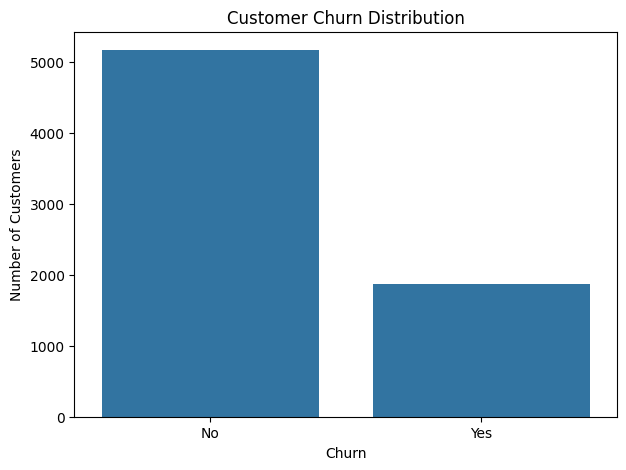

In [47]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [48]:
churn_distribution = (
    df["Churn"]
    .value_counts(normalize=True) * 100
)

print(churn_distribution.round(2))

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


In [50]:
print(
    df["Contract"].value_counts()
)

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64


In [51]:
contract_churn = (
    df.groupby("Contract")["Churn_Flag"]
    .mean() * 100
)

print(contract_churn.round(2))

Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn_Flag, dtype: float64


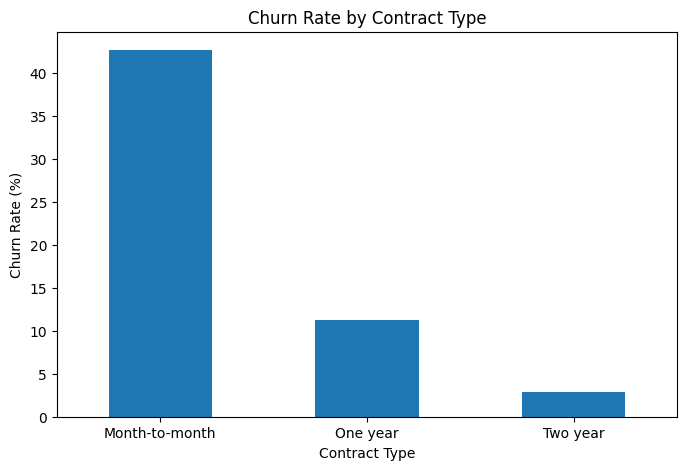

In [52]:
plt.figure(figsize=(8, 5))

contract_churn.sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [53]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [54]:
print(
    df["TenureGroup"].value_counts()
    .sort_index()
)

TenureGroup
0-12 Months     2175
13-24 Months    1024
25-48 Months    1594
49-72 Months    2239
Name: count, dtype: int64


In [55]:
tenure_churn = (
    df.groupby(
        "TenureGroup",
        observed=False
    )["Churn_Flag"].mean() * 100
)

print(tenure_churn.round(2))

TenureGroup
0-12 Months     47.68
13-24 Months    28.71
25-48 Months    20.39
49-72 Months     9.51
Name: Churn_Flag, dtype: float64


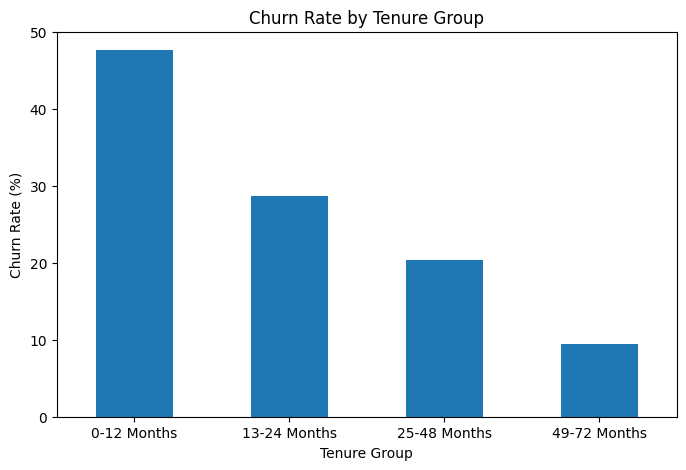

In [56]:
plt.figure(figsize=(8, 5))

tenure_churn.plot(kind="bar")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [57]:
print(
    df["InternetService"].value_counts()
)

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64


In [58]:
internet_churn = (
    df.groupby("InternetService")["Churn_Flag"]
    .mean() * 100
)

print(internet_churn.round(2))

InternetService
DSL            19.00
Fiber optic    41.89
No              7.43
Name: Churn_Flag, dtype: float64


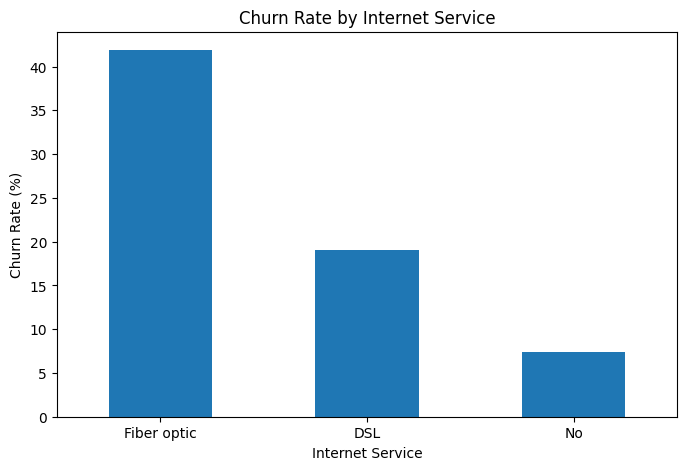

In [59]:
plt.figure(figsize=(8, 5))

internet_churn.sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [60]:
print(
    df["PaymentMethod"].value_counts()
)

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64


In [61]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn_Flag"]
    .mean() * 100
)

print(payment_churn.round(2))

PaymentMethod
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Electronic check             45.29
Mailed check                 19.20
Name: Churn_Flag, dtype: float64


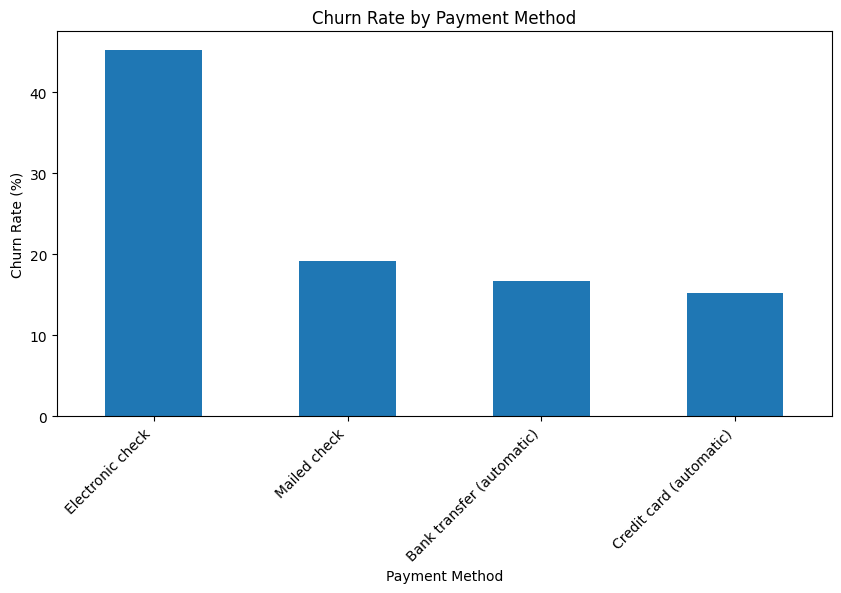

In [62]:
plt.figure(figsize=(10, 5))

payment_churn.sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.show()

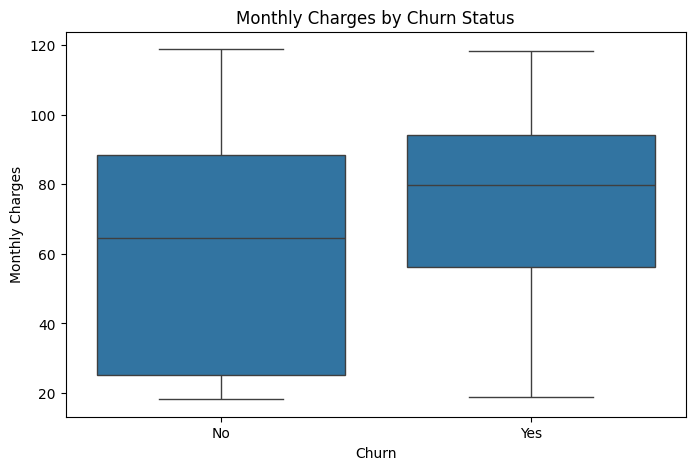

In [63]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [64]:
monthly_charge_churn = (
    df.groupby("Churn")["MonthlyCharges"]
    .mean()
)

print(monthly_charge_churn.round(2))

Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [65]:
gender_churn = (
    df.groupby("gender")["Churn_Flag"]
    .mean() * 100
)

print(gender_churn.round(2))

gender
Female    26.96
Male      26.20
Name: Churn_Flag, dtype: float64


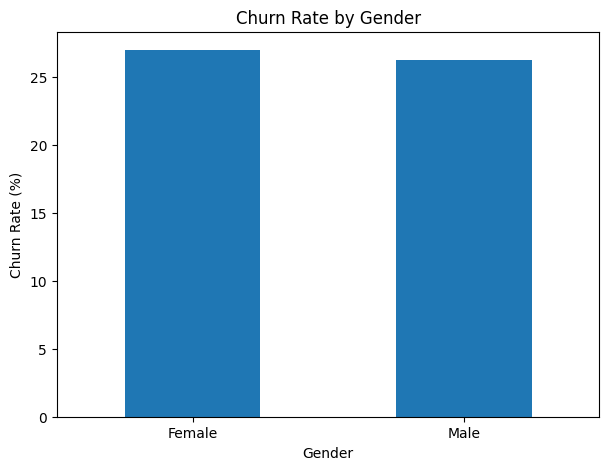

In [66]:
plt.figure(figsize=(7, 5))

gender_churn.plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [67]:
security_churn = (
    df.groupby("OnlineSecurity")["Churn_Flag"]
    .mean() * 100
)

print(security_churn.round(2))

OnlineSecurity
No                     41.78
No internet service     7.43
Yes                    14.64
Name: Churn_Flag, dtype: float64


In [68]:
support_churn = (
    df.groupby("TechSupport")["Churn_Flag"]
    .mean() * 100
)

print(support_churn.round(2))

TechSupport
No                     41.65
No internet service     7.43
Yes                    15.20
Name: Churn_Flag, dtype: float64


In [69]:
device_churn = (
    df.groupby("DeviceProtection")["Churn_Flag"]
    .mean() * 100
)

print(device_churn.round(2))

DeviceProtection
No                     39.14
No internet service     7.43
Yes                    22.54
Name: Churn_Flag, dtype: float64


In [70]:
senior_churn = (
    df.groupby("SeniorCitizen")["Churn_Flag"]
    .mean() * 100
)

print(senior_churn.round(2))

SeniorCitizen
0    23.65
1    41.68
Name: Churn_Flag, dtype: float64


In [71]:
paperless_churn = (
    df.groupby("PaperlessBilling")["Churn_Flag"]
    .mean() * 100
)

print(paperless_churn.round(2))

PaperlessBilling
No     16.38
Yes    33.59
Name: Churn_Flag, dtype: float64


In [72]:
partner_churn = (
    df.groupby("Partner")["Churn_Flag"]
    .mean() * 100
)

print(partner_churn.round(2))

Partner
No     32.98
Yes    19.72
Name: Churn_Flag, dtype: float64


In [73]:
dependents_churn = (
    df.groupby("Dependents")["Churn_Flag"]
    .mean() * 100
)

print(dependents_churn.round(2))

Dependents
No     31.28
Yes    15.53
Name: Churn_Flag, dtype: float64


In [74]:
churned_revenue = df.loc[
    df["Churn"] == "Yes",
    "MonthlyCharges"
].sum()

print(
    "Monthly Charges Associated with Churned Customers:",
    round(churned_revenue, 2)
)

Monthly Charges Associated with Churned Customers: 139130.85


In [75]:
retained_revenue = df.loc[
    df["Churn"] == "No",
    "MonthlyCharges"
].sum()

print(
    "Monthly Charges from Retained Customers:",
    round(retained_revenue, 2)
)

Monthly Charges from Retained Customers: 316530.15


In [76]:
churned_total_charges = df.loc[
    df["Churn"] == "Yes",
    "TotalCharges"
].sum()

print(
    "Total Charges Associated with Churned Customers:",
    round(churned_total_charges, 2)
)

Total Charges Associated with Churned Customers: 2862926.9


In [77]:
churned_total_charges = df.loc[
    df["Churn"] == "Yes",
    "TotalCharges"
].sum()

print(
    "Total Charges Associated with Churned Customers:",
    round(churned_total_charges, 2)
)

Total Charges Associated with Churned Customers: 2862926.9


In [78]:
median_monthly_charge = df["MonthlyCharges"].median()

df["RiskSegment"] = np.where(
    (df["Contract"] == "Month-to-month") &
    (df["tenure"] <= 12) &
    (df["MonthlyCharges"] >= median_monthly_charge),
    "High Risk",
    "Other"
)

In [79]:
print(
    df["RiskSegment"].value_counts()
)

RiskSegment
Other        6216
High Risk     816
Name: count, dtype: int64


In [80]:
risk_churn = (
    df.groupby("RiskSegment")["Churn_Flag"]
    .mean() * 100
)

print(risk_churn.round(2))

RiskSegment
High Risk    69.73
Other        20.91
Name: Churn_Flag, dtype: float64


In [ ]:
risk_customers = (
    df.groupby("RiskSegment")["customerID"]
    .nunique()
)

print(risk_customers)

In [81]:
high_risk_customers = df[
    df["RiskSegment"] == "High Risk"
]

print(
    "High Risk Customers:",
    len(high_risk_customers)
)

print(
    "High Risk Churned Customers:",
    (high_risk_customers["Churn"] == "Yes").sum()
)

High Risk Customers: 816
High Risk Churned Customers: 569


In [82]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Churn Rate (%)",
        "Retention Rate (%)",
        "Average Monthly Charges",
        "Average Total Charges",
        "Average Tenure (Months)",
        "Monthly Revenue",
        "Churned Customer Monthly Charges"
    ],

    "Value": [
        total_customers,
        churned_customers,
        retained_customers,
        round(churn_rate, 2),
        round(retention_rate, 2),
        round(avg_monthly_charges, 2),
        round(avg_total_charges, 2),
        round(avg_tenure, 2),
        round(monthly_revenue, 2),
        round(churned_revenue, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Customers,7032.00
1,Churned Customers,1869.00
2,Retained Customers,5163.00
3,Churn Rate (%),26.58
4,Retention Rate (%),73.42
5,Average Monthly Charges,64.80
6,Average Total Charges,2283.30
7,Average Tenure (Months),32.42
8,Monthly Revenue,455661.00
9,Churned Customer Monthly Charges,139130.85


In [83]:
print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (7032, 24)


In [84]:
print("Final Missing Values:")
print(df.isnull().sum())

Final Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_Flag          0
TenureGroup         0
RiskSegment         0
dtype: int64


In [85]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 0


In [86]:
print("Final Columns:")
print(df.columns.tolist())

Final Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Flag', 'TenureGroup', 'RiskSegment']


In [87]:
df.to_csv(
    "customer_churn_cleaned.csv",
    index=False
)

print(
    "customer_churn_cleaned.csv saved successfully!"
)

customer_churn_cleaned.csv saved successfully!


In [88]:
files.download(
    "customer_churn_cleaned.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>